# 01. Scaffold split from raw molecule tables

**Purpose.** Recompute Bemis-Murcko scaffolds from processed molecule tables and inspect no-scaffold allocation under scaffold splitting.

**Datasets.** Boiling point, pKb, Eye corrosion, and Micronucleus tox.

**Main outputs.**
- `scaffold_fold_allocation_summary.csv`
- `no_scaffold_fold_branch_summary.csv`

**Expected observation.** No-scaffold molecules are kept as one scaffold bucket and can dominate a fold when the bucket is large.

**Data source.** `data/demo/scaffold_from_scratch/`

In [ ]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start):
    for path in [start.resolve()] + list(start.resolve().parents):
        if (path / "src" / "empty_scaffold").exists() and (path / "data").exists():
            return path
    raise RuntimeError("Could not locate project root. Run this notebook inside the repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from empty_scaffold.scaffold_splitting import assign_scaffold_folds, summarize_fold_allocation, no_scaffold_fold, scaffold_kfolds_for_n
from empty_scaffold.data_utils import summarize_scaffolds

DATA_DIR = PROJECT_ROOT / "data" / "demo" / "scaffold_from_scratch"
OUT_DIR = PROJECT_ROOT / "outputs" / "notebook_01_scaffold_split"
OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 60)
pd.set_option("display.precision", 4)

print(f"Project root: {PROJECT_ROOT.name}")
print(f"Input directory: {DATA_DIR.relative_to(PROJECT_ROOT)}")
print(f"Output directory: {OUT_DIR.relative_to(PROJECT_ROOT)}")

## Dataset registry

Scaffolds and folds are recomputed from the processed molecule tables.

In [2]:
DATASETS = [
    {
        "dataset": "boiling_point",
        "display_name": "Boiling point",
        "file": "bp.csv",
        "prediction_type": "regression",
        "target": "label",
        "benchmark": "ADMET",
    },
    {
        "dataset": "pkb",
        "display_name": "pKb",
        "file": "pkb.csv",
        "prediction_type": "regression",
        "target": "label",
        "benchmark": "ADMET",
    },
    {
        "dataset": "eye_corrosion",
        "display_name": "Eye corrosion",
        "file": "eye_corrosion.csv",
        "prediction_type": "classification",
        "target": "eye_corrosion",
        "benchmark": "ADMET",
    },
    {
        "dataset": "micronucleus_tox",
        "display_name": "Genetic tox / micronucleus",
        "file": "micronucleus_tox.csv",
        "prediction_type": "classification",
        "target": "micronucleus_tox",
        "benchmark": "ADMET",
    },
]

registry = []
for spec in DATASETS:
    path = DATA_DIR / spec["file"]
    if not path.exists():
        raise FileNotFoundError(path)
    n_rows = len(pd.read_csv(path))
    registry.append({
        "dataset": spec["dataset"],
        "display_name": spec["display_name"],
        "prediction_type": spec["prediction_type"],
        "target": spec["target"],
        "file": str(path.relative_to(PROJECT_ROOT)),
        "n_rows": n_rows,
    })

pd.DataFrame(registry)

,dataset,display_name,prediction_type,target,file,n_rows
0,boiling_point,Boiling point,regression,label,data/demo/scaffold_from_scratch/bp.csv,5402
1,pkb,pKb,regression,label,data/demo/scaffold_from_scratch/pkb.csv,3662
2,eye_corrosion,Eye corrosion,classification,eye_corrosion,data/demo/scaffold_from_scratch/eye_corrosion.csv,2298
3,micronucleus_tox,Genetic tox / micronucleus,classification,micronucleus_tox,data/demo/scaffold_from_scratch/micronucleus_t...,641


## Recompute scaffolds and scaffold folds

Bemis-Murcko scaffolds are recomputed from molecular structures. Empty scaffold representations are grouped as one no-scaffold bucket.

In [3]:
folded_tables = {}
prevalence_rows = []
fold_summary_rows = []

for spec in DATASETS:
    raw = pd.read_csv(DATA_DIR / spec["file"])
    n_folds = scaffold_kfolds_for_n(len(raw))
    folded = assign_scaffold_folds(
        raw,
        smiles_col="molecules",
        n_folds=n_folds,
        dataset=spec["dataset"],
    )
    folded_tables[spec["dataset"]] = folded

    scaffold_summary = summarize_scaffolds(folded, spec["dataset"])
    scaffold_summary.update({
        "display_name": spec["display_name"],
        "benchmark": spec["benchmark"],
        "prediction_type": spec["prediction_type"],
        "target": spec["target"],
        "n_folds": n_folds,
    })
    prevalence_rows.append(scaffold_summary)

    fold_summary = summarize_fold_allocation(folded, spec["dataset"])
    fold_summary["display_name"] = spec["display_name"]
    fold_summary["prediction_type"] = spec["prediction_type"]
    fold_summary["no_scaffold_fold"] = no_scaffold_fold(folded)
    fold_summary["n_folds"] = n_folds
    fold_summary_rows.extend(fold_summary.to_dict("records"))

    folded.to_csv(OUT_DIR / f"{spec['dataset']}_with_scaffold_folds.csv", index=False)

prevalence = pd.DataFrame(prevalence_rows)
prevalence["no_scaffold_percent"] = 100 * prevalence["no_scaffold_proportion"]
prevalence = prevalence[[
    "dataset", "display_name", "prediction_type", "n_molecules", "n_no_scaffold",
    "no_scaffold_percent", "n_unique_nonempty_scaffolds", "n_folds", "target"
]].sort_values(["prediction_type", "display_name"]).reset_index(drop=True)

fold_summary = pd.DataFrame(fold_summary_rows).sort_values(["dataset", "fold"]).reset_index(drop=True)
fold_summary["no_scaffold_percent"] = 100 * fold_summary["no_scaffold_proportion"]

prevalence.to_csv(OUT_DIR / "scaffold_prevalence_summary.csv", index=False)
fold_summary.to_csv(OUT_DIR / "scaffold_fold_allocation_summary.csv", index=False)

prevalence

,dataset,display_name,prediction_type,n_molecules,n_no_scaffold,no_scaffold_percent,n_unique_nonempty_scaffolds,n_folds,target
0,eye_corrosion,Eye corrosion,classification,2298,553,24.0644,857,7,eye_corrosion
1,micronucleus_tox,Genetic tox / micronucleus,classification,641,233,36.3495,198,5,micronucleus_tox
2,boiling_point,Boiling point,regression,5402,2652,49.0929,455,10,label
3,pkb,pKb,regression,3662,591,16.1387,809,10,label


## Fold-level allocation

The fold containing the no-scaffold bucket is identified and summarized below.

In [4]:
fold_view = fold_summary[[
    "dataset", "display_name", "fold", "n_total", "n_no_scaffold",
    "no_scaffold_percent", "no_scaffold_fold",
]].copy()
fold_view

,dataset,display_name,fold,n_total,n_no_scaffold,no_scaffold_percent,no_scaffold_fold
0,boiling_point,Boiling point,0,186,0,0.0,6
1,boiling_point,Boiling point,1,186,0,0.0,6
2,boiling_point,Boiling point,2,186,0,0.0,6
3,boiling_point,Boiling point,3,186,0,0.0,6
4,boiling_point,Boiling point,4,186,0,0.0,6
5,boiling_point,Boiling point,5,187,0,0.0,6
6,boiling_point,Boiling point,6,2652,2652,100.0,6
7,boiling_point,Boiling point,7,186,0,0.0,6
8,boiling_point,Boiling point,8,1260,0,0.0,6
9,boiling_point,Boiling point,9,187,0,0.0,6


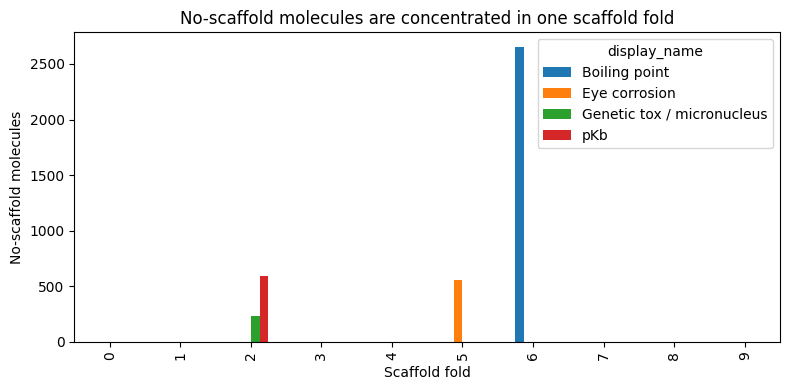

Saved: outputs/notebook_01_scaffold_split/no_scaffold_counts_by_fold.png


In [5]:
plot_fold = fold_summary.pivot(index="fold", columns="display_name", values="n_no_scaffold").fillna(0)
ax = plot_fold.plot(kind="bar", figsize=(8, 4))
ax.set_xlabel("Scaffold fold")
ax.set_ylabel("No-scaffold molecules")
ax.set_title("No-scaffold molecules are concentrated in one scaffold fold")
plt.tight_layout()
fig_path = OUT_DIR / "no_scaffold_counts_by_fold.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")

## Branch summaries for the selected no-scaffold fold

The selected no-scaffold fold is treated as the test branch. The remaining folds are assigned to training and validation branches.

In [6]:
def branch_summary_for_eval_fold(folded, eval_fold, valid_fold=None):
    if valid_fold is None:
        valid_fold = (eval_fold + 1) % int(folded["fold"].nunique())
    if valid_fold == eval_fold:
        raise ValueError("valid_fold must differ from eval_fold")

    parts = {
        "train": folded.loc[~folded["fold"].isin([eval_fold, valid_fold])],
        "valid": folded.loc[folded["fold"] == valid_fold],
        "test": folded.loc[folded["fold"] == eval_fold],
    }
    rows = []
    for branch, part in parts.items():
        n_total = int(len(part))
        n_ns = int(part["no_scaffold"].sum())
        rows.append({
            "branch": branch,
            "folds": ",".join(map(str, sorted(part["fold"].unique()))) if n_total else "",
            "n_total": n_total,
            "n_no_scaffold": n_ns,
            "no_scaffold_proportion": n_ns / n_total if n_total else np.nan,
            "no_scaffold_percent": 100 * n_ns / n_total if n_total else np.nan,
        })
    return pd.DataFrame(rows)

branch_rows = []
for spec in DATASETS:
    folded = folded_tables[spec["dataset"]]
    eval_fold = no_scaffold_fold(folded)
    valid_fold = (eval_fold + 1) % int(folded["fold"].nunique())
    branch_df = branch_summary_for_eval_fold(folded, eval_fold, valid_fold=valid_fold)
    branch_df.insert(0, "dataset", spec["dataset"])
    branch_df.insert(1, "display_name", spec["display_name"])
    branch_df.insert(2, "prediction_type", spec["prediction_type"])
    branch_df.insert(3, "no_scaffold_fold", eval_fold)
    branch_rows.extend(branch_df.to_dict("records"))

branch_summary = pd.DataFrame(branch_rows)
branch_summary.to_csv(OUT_DIR / "no_scaffold_fold_branch_summary.csv", index=False)
branch_summary

,dataset,display_name,prediction_type,no_scaffold_fold,branch,folds,n_total,n_no_scaffold,no_scaffold_proportion,no_scaffold_percent
0,boiling_point,Boiling point,regression,6,train,"0,1,2,3,4,5,8,9",2564,0,0.0,0.0
1,boiling_point,Boiling point,regression,6,valid,7,186,0,0.0,0.0
2,boiling_point,Boiling point,regression,6,test,6,2652,2652,1.0,100.0
3,pkb,pKb,regression,2,train,"0,1,4,5,6,7,8,9",2756,0,0.0,0.0
4,pkb,pKb,regression,2,valid,3,315,0,0.0,0.0
5,pkb,pKb,regression,2,test,2,591,591,1.0,100.0
6,eye_corrosion,Eye corrosion,classification,5,train,"0,1,2,3,4",1472,0,0.0,0.0
7,eye_corrosion,Eye corrosion,classification,5,valid,6,273,0,0.0,0.0
8,eye_corrosion,Eye corrosion,classification,5,test,5,553,553,1.0,100.0
9,micronucleus_tox,Genetic tox / micronucleus,classification,2,train,"0,1,4",306,0,0.0,0.0


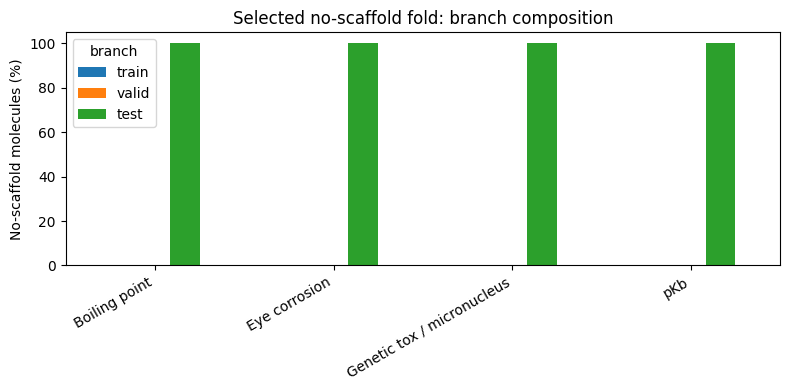

Saved: outputs/notebook_01_scaffold_split/no_scaffold_fold_branch_composition.png


In [7]:
plot_branch = branch_summary.pivot(index="display_name", columns="branch", values="no_scaffold_percent")
plot_branch = plot_branch[["train", "valid", "test"]]
ax = plot_branch.plot(kind="bar", figsize=(8, 4))
ax.set_xlabel("")
ax.set_ylabel("No-scaffold molecules (%)")
ax.set_title("Selected no-scaffold fold: branch composition")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fig_path = OUT_DIR / "no_scaffold_fold_branch_composition.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")

## Target and label distribution checks

Regression datasets are summarized by target-distribution differences between no-scaffold and scaffold-bearing molecules. Classification datasets are summarized by positive-rate differences.

In [8]:
def empirical_ks(x, y):
    x = np.sort(np.asarray(x, dtype=float))
    y = np.sort(np.asarray(y, dtype=float))
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan
    values = np.sort(np.unique(np.concatenate([x, y])))
    cdf_x = np.searchsorted(x, values, side="right") / len(x)
    cdf_y = np.searchsorted(y, values, side="right") / len(y)
    return float(np.max(np.abs(cdf_x - cdf_y)))


def hedges_g(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) < 2 or len(y) < 2:
        return np.nan
    nx, ny = len(x), len(y)
    sx2, sy2 = np.var(x, ddof=1), np.var(y, ddof=1)
    pooled = np.sqrt(((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2))
    if pooled == 0:
        return np.nan
    d = (np.mean(x) - np.mean(y)) / pooled
    correction = 1 - 3 / (4 * (nx + ny) - 9)
    return float(correction * d)


def bernoulli_js(p, q):
    eps = 1e-12
    p = float(np.clip(p, eps, 1 - eps))
    q = float(np.clip(q, eps, 1 - eps))
    m = 0.5 * (p + q)

    def kl_bern(a, b):
        return a * np.log(a / b) + (1 - a) * np.log((1 - a) / (1 - b))

    return float(0.5 * kl_bern(p, m) + 0.5 * kl_bern(q, m))


distribution_rows = []
for spec in DATASETS:
    folded = folded_tables[spec["dataset"]]
    target = spec["target"]
    values = pd.to_numeric(folded[target], errors="coerce")
    ns = folded["no_scaffold"].to_numpy(dtype=bool)

    if spec["prediction_type"] == "regression":
        x = values[ns].dropna().to_numpy()
        y = values[~ns].dropna().to_numpy()
        distribution_rows.append({
            "dataset": spec["dataset"],
            "display_name": spec["display_name"],
            "prediction_type": spec["prediction_type"],
            "n_no_scaffold_labeled": int(len(x)),
            "n_scaffold_bearing_labeled": int(len(y)),
            "no_scaffold_mean": float(np.mean(x)) if len(x) else np.nan,
            "scaffold_bearing_mean": float(np.mean(y)) if len(y) else np.nan,
            "abs_hedges_g": abs(hedges_g(x, y)),
            "ks_statistic": empirical_ks(x, y),
            "positive_rate_no_scaffold": np.nan,
            "positive_rate_scaffold_bearing": np.nan,
            "abs_delta_positive_rate": np.nan,
            "bernoulli_js": np.nan,
        })
    else:
        x = values[ns].dropna().to_numpy()
        y = values[~ns].dropna().to_numpy()
        p_ns = float(np.mean(x)) if len(x) else np.nan
        p_sb = float(np.mean(y)) if len(y) else np.nan
        distribution_rows.append({
            "dataset": spec["dataset"],
            "display_name": spec["display_name"],
            "prediction_type": spec["prediction_type"],
            "n_no_scaffold_labeled": int(len(x)),
            "n_scaffold_bearing_labeled": int(len(y)),
            "no_scaffold_mean": np.nan,
            "scaffold_bearing_mean": np.nan,
            "abs_hedges_g": np.nan,
            "ks_statistic": np.nan,
            "positive_rate_no_scaffold": p_ns,
            "positive_rate_scaffold_bearing": p_sb,
            "abs_delta_positive_rate": abs(p_ns - p_sb) if np.isfinite(p_ns) and np.isfinite(p_sb) else np.nan,
            "bernoulli_js": bernoulli_js(p_ns, p_sb) if np.isfinite(p_ns) and np.isfinite(p_sb) else np.nan,
        })

distribution_summary = pd.DataFrame(distribution_rows)
distribution_summary.to_csv(OUT_DIR / "target_label_distribution_shift_summary.csv", index=False)
distribution_summary

,dataset,display_name,prediction_type,n_no_scaffold_labeled,n_scaffold_bearing_labeled,no_scaffold_mean,scaffold_bearing_mean,abs_hedges_g,ks_statistic,positive_rate_no_scaffold,positive_rate_scaffold_bearing,abs_delta_positive_rate,bernoulli_js
0,boiling_point,Boiling point,regression,2652,2750,149.1121,227.6702,1.0421,0.4640,NaN,NaN,NaN,NaN
1,pkb,pKb,regression,591,3071,8.8644,6.1158,0.8901,0.4366,NaN,NaN,NaN,NaN
2,eye_corrosion,Eye corrosion,classification,553,1745,NaN,NaN,NaN,NaN,0.8644,0.2332,0.6311,0.2183
3,micronucleus_tox,Genetic tox / micronucleus,classification,233,408,NaN,NaN,NaN,NaN,0.1845,0.5417,0.3571,0.0712


## Generated files

In [9]:
for path in sorted(OUT_DIR.glob("*.csv")) + sorted(OUT_DIR.glob("*.png")):
    print(path.relative_to(PROJECT_ROOT))

outputs/notebook_01_scaffold_split/boiling_point_with_scaffold_folds.csv
outputs/notebook_01_scaffold_split/eye_corrosion_with_scaffold_folds.csv
outputs/notebook_01_scaffold_split/micronucleus_tox_with_scaffold_folds.csv
outputs/notebook_01_scaffold_split/no_scaffold_fold_branch_summary.csv
outputs/notebook_01_scaffold_split/pkb_with_scaffold_folds.csv
outputs/notebook_01_scaffold_split/scaffold_fold_allocation_summary.csv
outputs/notebook_01_scaffold_split/scaffold_prevalence_summary.csv
outputs/notebook_01_scaffold_split/target_label_distribution_shift_summary.csv
outputs/notebook_01_scaffold_split/no_scaffold_counts_by_fold.png
outputs/notebook_01_scaffold_split/no_scaffold_fold_branch_composition.png
